In [10]:
import pandas as pd
import numpy as np

def clean_hardware_catalog(file_path):
    df = pd.read_csv(file_path)
    print(f"Loaded dataset. Rows: {len(df)}")

    report = {
        "dropped_missing_product_name": 0,
        "unknown_to_null": 0,
        "geo_corrections": 0,
        "negative_values_fixed": 0,
        "bad_dates_removed": 0,
        "bad_details_removed": 0
    }

    # Normalize "unknown" values
    unknown_counts = df.isin(['unknown', 'UNKNOWN', 'Unknown', ' unknown']).sum().sum()
    df.replace(r'(?i)^\s*unknown\s*$', np.nan, regex=True, inplace=True)
    report["unknown_to_null"] = unknown_counts

    # Drop missing product names
    before = len(df)
    df = df.dropna(subset=['PRODUCT_NAME'])
    report["dropped_missing_product_name"] = before - len(df)

    # Country normalization
    country_map = {
        'United States of America': 'United States',
        'US': 'United States',
        'IN': 'India',
        'AU': 'Australia',
        'CN': 'China'
    }
    df['COUNTRY_NAME'] = df['COUNTRY_NAME'].replace(country_map)

    geo_map = {
        'San Francisco': {'STATE': 'California', 'COUNTRY_NAME': 'United States'},
        'Seattle': {'STATE': 'Washington', 'COUNTRY_NAME': 'United States'},
        'South Brunswick': {'STATE': 'New Jersey', 'COUNTRY_NAME': 'United States'},
        'Beijing': {'STATE': 'Beijing', 'COUNTRY_NAME': 'China'},
        'Bombay': {'STATE': 'Maharashtra', 'COUNTRY_NAME': 'India'},
        'Mumbai': {'STATE': 'Maharashtra', 'COUNTRY_NAME': 'India'},
        'Mexico City': {'STATE': 'Nuevo Leon', 'COUNTRY_NAME': 'Mexico'},
        'Monterrey': {'STATE': 'Nuevo Leon', 'COUNTRY_NAME': 'Mexico'},
        'Sydney': {'STATE': 'New South Wales', 'COUNTRY_NAME': 'Australia'},
        'Toronto': {'STATE': 'Ontario', 'COUNTRY_NAME': 'Canada'}
    }

    df.loc[df['COUNTRY_NAME'] == 'Southlake', 'CITY'] = 'Southlake'

    df['CITY'] = df['CITY'].fillna(df['WAREHOUSE_NAME'])
    df['WAREHOUSE_NAME'] = df['WAREHOUSE_NAME'].fillna(df['CITY'])

    corrections = 0
    for city, geo in geo_map.items():
        mask = df['CITY'] == city

        if mask.any():
            wrong = mask & (
                (df['COUNTRY_NAME'] != geo['COUNTRY_NAME']) |
                df['COUNTRY_NAME'].isna() |
                (df['STATE'] != geo['STATE']) |
                df['STATE'].isna()
            )

            corrections += wrong.sum()
            df.loc[mask, ['COUNTRY_NAME', 'STATE']] = geo.values()

    report["geo_corrections"] = corrections

    # Numeric cleanup
    for col in ['ACQUISITION_COST', 'SALE_COST', 'QUANTITY']:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            report["negative_values_fixed"] += (df[col] < 0).sum()
            df[col] = df[col].abs()

    df['QUANTITY'] = df['QUANTITY'].fillna(0)

    # Date cleanup
    dates = pd.to_datetime(df['CREATION_DATE'], errors='coerce')
    bad_dates = (dates.dt.year < 1990) | (dates.dt.year > 2026) | dates.isna()

    report["bad_dates_removed"] = bad_dates.sum()
    df['CREATION_DATE'] = dates
    df.loc[bad_dates, 'CREATION_DATE'] = pd.NaT

    # Details cleanup
    if 'ADDITIONAL_DETAILS' in df:
        s = df['ADDITIONAL_DETAILS'].astype(str)
        bad = (~s.str.contains(':')) & df['ADDITIONAL_DETAILS'].notna()

        report["bad_details_removed"] = bad.sum()
        df.loc[bad, 'ADDITIONAL_DETAILS'] = np.nan

    print("\n" + "="*50)
    print("CLEANING REPORT")
    print("="*50)
    for k, v in report.items():
        print(f"{k}: {v}")
    print(f"final_rows: {len(df)}")
    print("="*50)

    df.to_csv('hardware_catalog_clean.csv', index=False)
    return df


clean_df = clean_hardware_catalog('/content/sample_data/hardware_catalog - hardware_catalog.csv')

Loaded dataset. Rows: 1112

CLEANING REPORT
dropped_missing_product_name: 17
unknown_to_null: 2
geo_corrections: 315
negative_values_fixed: 3
bad_dates_removed: 680
bad_details_removed: 3
final_rows: 1095


In [11]:
def prepare_hardware_data(input_path):
    df = pd.read_csv(input_path)
    print(f"Loaded clean data: {len(df)} rows")

    # Split details into 4 fields
    details = df['ADDITIONAL_DETAILS'].fillna('')
    split = details.str.split(',', expand=True)

    for i in range(4):
        if i not in split:
            split[i] = np.nan

    df['DETAIL_1'] = split[0].replace('', np.nan)
    df['DETAIL_2'] = split[1].replace('', np.nan)
    df['DETAIL_3'] = split[2].replace('', np.nan)
    df['DETAIL_4'] = split[3].replace('', np.nan)

    print("Details parsed")

    # Profit metrics
    df['PROFIT'] = df['SALE_COST'] - df['ACQUISITION_COST']
    df['TOTAL_PROFIT'] = df['PROFIT'] * df['QUANTITY']

    print("Profit calculated")

    # Tax logic
    def tax(row):
        if pd.isna(row['TOTAL_PROFIT']) or row['TOTAL_PROFIT'] <= 0:
            return row['TOTAL_PROFIT']

        country = str(row['COUNTRY_NAME']).strip()
        city = str(row['CITY']).strip()

        if city == 'Southlake':
            rate = 0.25 if row['QUANTITY'] > 150 else 0.10
        elif country == 'China':
            rate = 0.50
        elif country == 'Mexico':
            rate = 0.30
        elif country == 'Australia':
            rate = 0.25
        else:
            rate = 0.0

        return row['TOTAL_PROFIT'] * (1 - rate)

    df['PROFIT_AFTER_TAX'] = df.apply(tax, axis=1)

    df.to_csv('assignment_output.csv', index=False)
    print("Saved output")

    return df


final_df = prepare_hardware_data('hardware_catalog_clean.csv')

Loaded clean data: 1095 rows
Details parsed
Profit calculated
Saved output


In [13]:
import duckdb
import pandas as pd

# Load dataset
df = pd.read_csv('assignment_output.csv')

# Filter taxonomy target rows
taxonomy = df[df['TAXONOMY_INDEX'].astype(str).str.lower() == 'true'].copy()

def classify(row):
    name = str(row['PRODUCT_NAME']).upper()
    det = str(row['ADDITIONAL_DETAILS']).upper()

    # 3-Level Taxonomy Mapping (L1, L2, L3)
    if 'SSD' in name or 'SATA' in det:
        return 'Hardware', 'Storage', 'SSD'
    if 'HDD' in name:
        return 'Hardware', 'Storage', 'HDD'
    if 'XEON' in name:
        return 'Hardware', 'CPU', 'Server CPU'
    if 'RYZEN' in name or 'CORE I' in name:
        return 'Hardware', 'CPU', 'Desktop CPU'
    if 'GTX' in name or 'RTX' in name:
        return 'Hardware', 'GPU', 'Graphics'
    if 'RAM' in det or 'DDR' in det:
        return 'Hardware', 'Memory', 'RAM'

    return 'Hardware', 'Other', 'Unclassified'

# Apply taxonomy classification and export
taxonomy[['L1','L2','L3']] = taxonomy.apply(lambda r: pd.Series(classify(r)), axis=1)
taxonomy.to_csv('taxonomy_output.csv', index=False)

print("Taxonomy processing completed successfully.")


# SQL ANALYSIS SECTION
print("\n--- SQL EXECUTION RESULTS ---")

# Query 1: Order volume by city
query1 = """
SELECT CITY, COUNT(*) AS Order_Count
FROM df
WHERE CITY IS NOT NULL
GROUP BY CITY
ORDER BY Order_Count DESC
"""
print("\n[Query 1: Top Cities by Orders]")
print(duckdb.query(query1).to_df())

# Query 2: High volume transactions
query2 = """
SELECT PRODUCT_NAME, QUANTITY
FROM df
WHERE QUANTITY > 150
"""
print("\n[Query 2: High-Quantity Orders (>150)]")
print(duckdb.query(query2).to_df().head())

# Query 3: Extract RAM specifications
query3 = """
SELECT PRODUCT_NAME,
       regexp_extract(ADDITIONAL_DETAILS, '([0-9]+)(GB)', 1) AS RAM_Size_GB
FROM df
WHERE ADDITIONAL_DETAILS LIKE '%GB%'
LIMIT 5
"""
print("\n[Query 3: Regex RAM Size Extraction]")
print(duckdb.query(query3).to_df())

# Query 4: Top profitable manufacturer
query4 = """
WITH profit_summary AS (
  SELECT split_part(PRODUCT_NAME, ' ', 1) AS Company_Name,
         SUM(TOTAL_PROFIT) AS Total_Net_Profit
  FROM df
  GROUP BY 1
)
SELECT * FROM profit_summary
ORDER BY Total_Net_Profit DESC
LIMIT 1
"""
print("\n[Query 4: Most Profitable Manufacturer]")
print(duckdb.query(query4).to_df())

Taxonomy processing completed successfully.

--- SQL EXECUTION RESULTS ---

[Query 1: Top Cities by Orders]
                        CITY  Order_Count
0                     Sydney          197
1                    Beijing          173
2        South San Francisco          164
3                     Bombay          126
4                    Toronto          113
5                    Seattle          109
6                  Monterrey           94
7            South Brunswick           48
8                  Southlake           36
9              San Francisco           30
10  United States of America            2
11               Mexico City            1
12                     India            1
13                     China            1

[Query 2: High-Quantity Orders (>150)]
                           PRODUCT_NAME  QUANTITY
0                 Samsung MZ-75E120B/AM     227.0
1            Gigabyte GV-N1070WF2OC-8GD     196.0
2                 Asus X99-E WS/USB 3.1     172.0
3            Supermicr

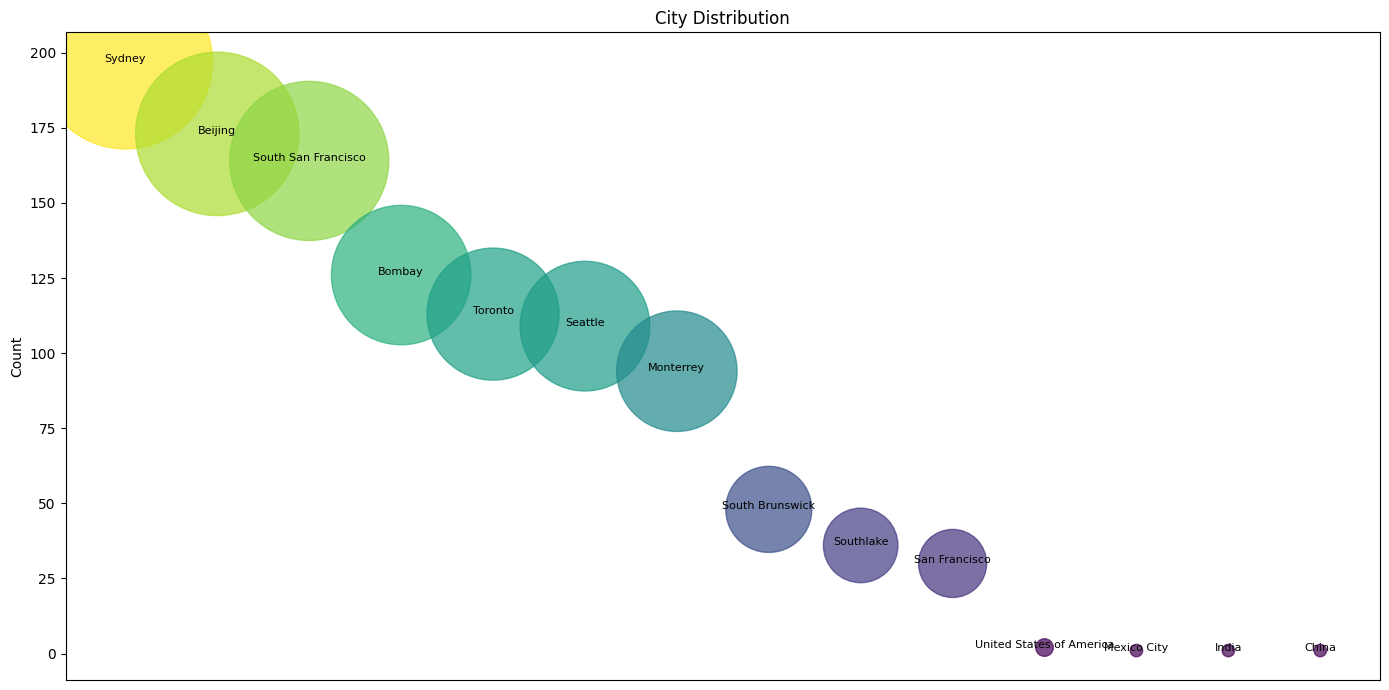

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("hardware_catalog_clean.csv")

city = df["CITY"].dropna().value_counts().reset_index()
city.columns = ["CITY", "COUNT"]
city = city.sort_values("COUNT", ascending=False)

x = np.arange(len(city))

plt.figure(figsize=(14,7))

plt.scatter(
    x,
    city["COUNT"],
    s=city["COUNT"] * 80,
    c=city["COUNT"],
    alpha=0.7
)

for i, r in city.iterrows():
    plt.text(i, r["COUNT"], r["CITY"], ha='center', fontsize=8)

plt.xticks([])
plt.ylabel("Count")
plt.title("City Distribution")
plt.tight_layout()
plt.show()